In [27]:
import os
import pandas as pd
import numpy as np
import re
from IPython.display import display
def merge_dataframe(data_path):
    item_list = os.listdir(data_path)
    pattern = re.compile(".*_(\w*)_.*", re.DOTALL)
    matches = [pattern.search(data) for data in item_list]
    names = [(item[0].group(1), item[1]) for item in zip(matches, item_list) if item[0]]
    first_data_path = os.path.join(data_path, names[0][1])
    df = pd.read_csv(first_data_path)
    df = df.assign(LOCATION=lambda x: names[0][0])
    for i in range(1, len(names)):
        unit_data_path = os.path.join(data_path, names[i][1])
        df_unit = pd.read_csv(unit_data_path)
        df_unit = df_unit.assign(LOCATION = lambda x: names[i][0])
        df = pd.concat([df, df_unit], axis = 0)
    return df
df = merge_dataframe("data/origin")


In [28]:
df.info()
df["Date"] = pd.to_datetime(df["Date"], format="%d/%m/%Y")
df = df.replace("-", np.nan)

<class 'pandas.core.frame.DataFrame'>
Index: 14979 entries, 0 to 862
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Date      14979 non-null  object
 1   VN_AQI    14979 non-null  int64 
 2   CO        14979 non-null  object
 3   NO2       14979 non-null  object
 4   PM-10     14979 non-null  object
 5   PM-2-5    14979 non-null  object
 6   SO2       14979 non-null  object
 7   LOCATION  14979 non-null  object
dtypes: int64(1), object(7)
memory usage: 1.0+ MB


In [29]:
df.head()

,Date,VN_AQI,CO,NO2,PM-10,PM-2-5,SO2,LOCATION
0,2025-10-06,51,17,17,51,25,3,HiepThanh
1,2025-10-05,48,17,13,48,27,3,HiepThanh
2,2025-10-04,57,16,21,57,43,2,HiepThanh
3,2025-10-03,46,20,27,46,26,2,HiepThanh
4,2025-10-02,52,18,24,52,33,2,HiepThanh


In [30]:
numeric_columns = ["CO", "NO2", "PM-10", "PM-2-5", "SO2"]
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col])
    df[col] = df[col].fillna(df[col].median())


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14979 entries, 0 to 862
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      14979 non-null  datetime64[ns]
 1   VN_AQI    14979 non-null  int64         
 2   CO        14979 non-null  float64       
 3   NO2       14979 non-null  float64       
 4   PM-10     14979 non-null  float64       
 5   PM-2-5    14979 non-null  float64       
 6   SO2       14979 non-null  float64       
 7   LOCATION  14979 non-null  object        
dtypes: datetime64[ns](1), float64(5), int64(1), object(1)
memory usage: 1.0+ MB


In [32]:
from sklearn.preprocessing import StandardScaler
sd = StandardScaler()

x = df.iloc[:, 1:-1].values
y = df.iloc[:,-1].values
x = sd.fit_transform(x)
x, y

(array([[-0.20132301,  0.08605887, -0.04883173,  0.80671899, -0.5170717 ,
         -0.48520623],
        [-0.26192057,  0.08605887, -0.27479731,  0.67874244, -0.46523875,
         -0.48520623],
        [-0.08012789,  0.05318435,  0.17713384,  1.06267207, -0.05057511,
         -0.55503755],
        ...,
        [-0.70630267, -0.37418446, -0.72672845, -1.15558799, -0.9835683 ,
         -0.55503755],
        [-0.68610348,  0.21755696, -0.38778009, -1.11292914, -0.93173534,
         -0.62486887],
        [ 8.86811169, 15.96445377,  5.14837642, -1.11292914, -0.93173534,
          4.05382957]], shape=(14979, 6)),
 array(['HiepThanh', 'HiepThanh', 'HiepThanh', ..., 'TraVinh', 'TraVinh',
        'TraVinh'], shape=(14979,), dtype=object))

In [33]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
x_2d=pca.fit_transform(x)


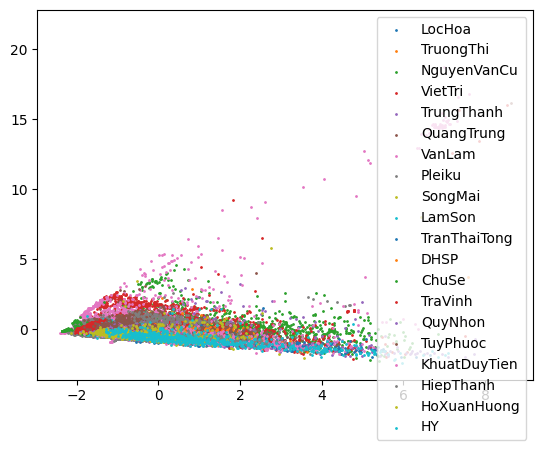

In [34]:
import matplotlib.pyplot as plt
label_set = set(y)
for label in label_set:
    x_draw = [item for idx, item in enumerate(x_2d[:, 0]) if y[idx] == label]
    y_draw = [item for idx, item in enumerate(x_2d[:, 1]) if y[idx] == label]
    plt.scatter(x_draw, y_draw, s=1, label=label)
plt.legend(loc="best")
plt.show()

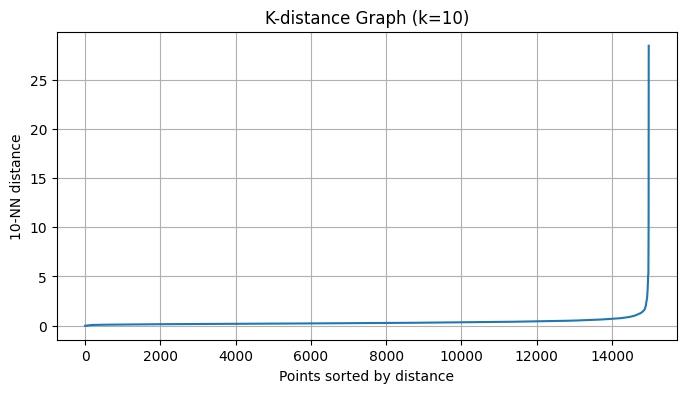

In [35]:
from sklearn.neighbors import NearestNeighbors

optimal_min_pts = 10
nearest_neighbors = NearestNeighbors(n_neighbors=optimal_min_pts)
nearest_neighbors.fit(x)
distances, _ = nearest_neighbors.kneighbors(x)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 4))
plt.plot(k_distances)
plt.title(f"K-distance Graph (k={optimal_min_pts})")
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{optimal_min_pts}-NN distance")
plt.grid(True)
plt.show()

In [36]:
from sklearn.cluster import DBSCAN
optimal_min_pts=10
optimal_eps=2
dbscan = DBSCAN(eps = optimal_eps, min_samples=optimal_min_pts)
labels = dbscan.fit_predict(x)

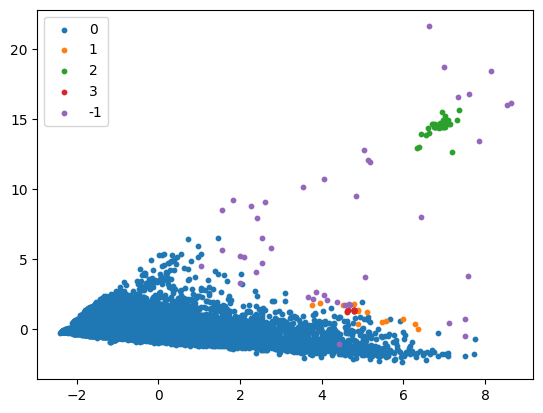

In [37]:
dbscan_label_set = set(labels)
for label in dbscan_label_set:
    x_draw = [item for idx, item in enumerate(x_2d[:, 0]) if labels[idx] == label]
    y_draw = [item for idx, item in enumerate(x_2d[:, 1]) if labels[idx] == label]
    plt.scatter(x_draw, y_draw,s =10, label = label)
plt.legend()
plt.show()

In [38]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print(f"--- Kết quả Phân cụm Cơ bản ---")
print(f"Tham số sử dụng: eps={optimal_eps}, MinPts={optimal_min_pts}")
print(f"Tổng số điểm dữ liệu: {len(x)}")
print(f"Số lượng cụm được tìm thấy: {n_clusters}")
print(f"Số lượng điểm nhiễu (label -1): {n_noise} (Chiếm {(n_noise / len(x)) * 100:.2f}%)")


# ====================================================================
# PHẦN 3: ĐÁNH GIÁ MÔ HÌNH (Sử dụng các Metric nội bộ)
# ====================================================================

# Điều kiện: Chỉ tính các Metric trên dữ liệu đã được phân cụm thành công 
# (loại bỏ các điểm nhiễu có label = -1)
# Đồng thời cần đảm bảo có ít nhất 2 cụm để tính các metric này.
core_samples_mask = (labels != -1)
X_core = x[core_samples_mask]
labels_core = labels[core_samples_mask]

print(f"\n--- Tính toán Metric trên {len(X_core)} điểm (Loại bỏ nhiễu) ---")

# Kiểm tra điều kiện có ít nhất 2 cụm
if len(np.unique(labels_core)) > 1:
    
    # 1. Silhouette Score (Chỉ số Hình bóng) - Càng gần 1 càng tốt
    silhouette = silhouette_score(X_core, labels_core)
    print(f"1. Silhouette Score: {silhouette:.4f}")
    
    # 2. Davies-Bouldin Index (DBI) - Càng thấp càng tốt
    davies_bouldin = davies_bouldin_score(X_core, labels_core)
    print(f"2. Davies-Bouldin Index (DBI): {davies_bouldin:.4f}")
    
    # 3. Calinski-Harabasz Index (CH Index) - Càng cao càng tốt
    calinski_harabasz = calinski_harabasz_score(X_core, labels_core)
    print(f"3. Calinski-Harabasz Index (CH Index): {calinski_harabasz:.4f}")
    
else:
    print("\n[LƯU Ý] Không đủ cụm (cần ít nhất 2 cụm, không tính nhiễu) để tính toán các Metric.")
    print("Bạn cần tối ưu hóa tham số eps và min_samples để tìm ra cấu trúc cụm rõ ràng hơn.")

--- Kết quả Phân cụm Cơ bản ---
Tham số sử dụng: eps=2, MinPts=10
Tổng số điểm dữ liệu: 14979
Số lượng cụm được tìm thấy: 4
Số lượng điểm nhiễu (label -1): 44 (Chiếm 0.29%)

--- Tính toán Metric trên 14935 điểm (Loại bỏ nhiễu) ---
1. Silhouette Score: 0.6366
2. Davies-Bouldin Index (DBI): 0.2616
3. Calinski-Harabasz Index (CH Index): 1193.2288
1. Silhouette Score: 0.6366
2. Davies-Bouldin Index (DBI): 0.2616
3. Calinski-Harabasz Index (CH Index): 1193.2288
